In [2]:
!conda install -y -q napari[all]


Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/mutterer/miniforge3/envs/training00

  added / updated specs:
    - napari


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bermuda-0.1.7              |  py314ha5689aa_0         361 KB  conda-forge
    cytoolz-1.1.0              |  py314h5bd0f2a_2         626 KB  conda-forge
    google-crc32c-1.8.0        |  py314hd6bf2bd_1          26 KB  conda-forge
    llvmlite-0.47.0            |  py314h946fb2a_1        32.6 MB  conda-forge
    msgpack-python-1.1.2       |  py314h9891dd4_1         101 KB  conda-forge
    numba-0.65.1               |  py314h8169c2f_1         5.5 MB  conda-forge
    numcodecs-0.16.5           |  py314ha0b5721_0         791 KB  conda-forge
    partsegcore-compiled-backend-0.15.14|  py314ha0b5721_1         863 KB  conda-forge
    pip-26.

In [3]:
import napari
from napari.utils import nbscreenshot
from skimage.data import cells3d

/home/mutterer/miniforge3/envs/training00/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
nuc = cells3d()[:, 1, :, :]
mem = cells3d()[:, 0, :, :]

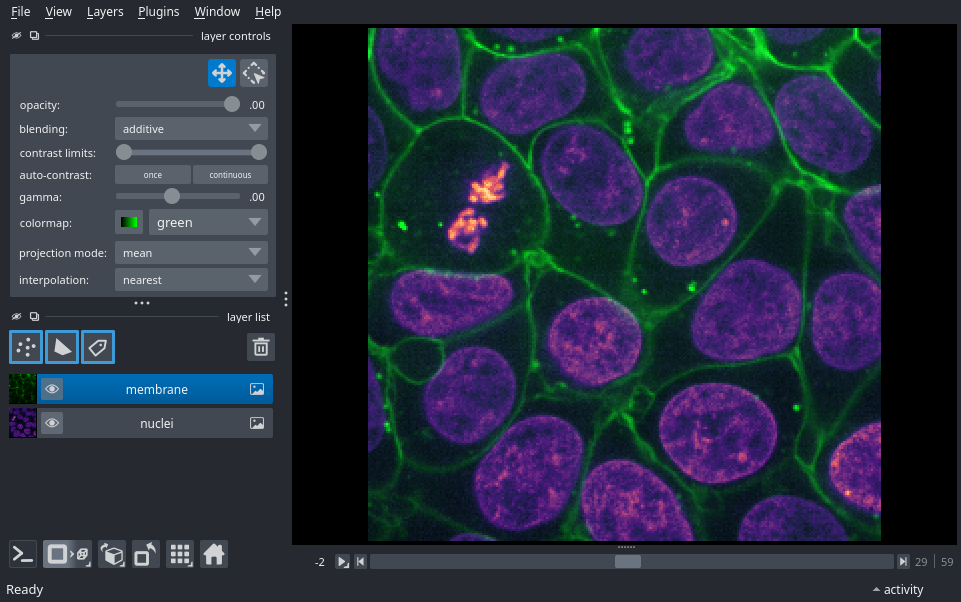

In [5]:
viewer = napari.Viewer()
viewer.add_image(nuc, name='nuclei', colormap='magma')
viewer.add_image(mem, name='membrane', blending='additive', colormap='green', contrast_limits=(0,20000))
nbscreenshot(viewer)

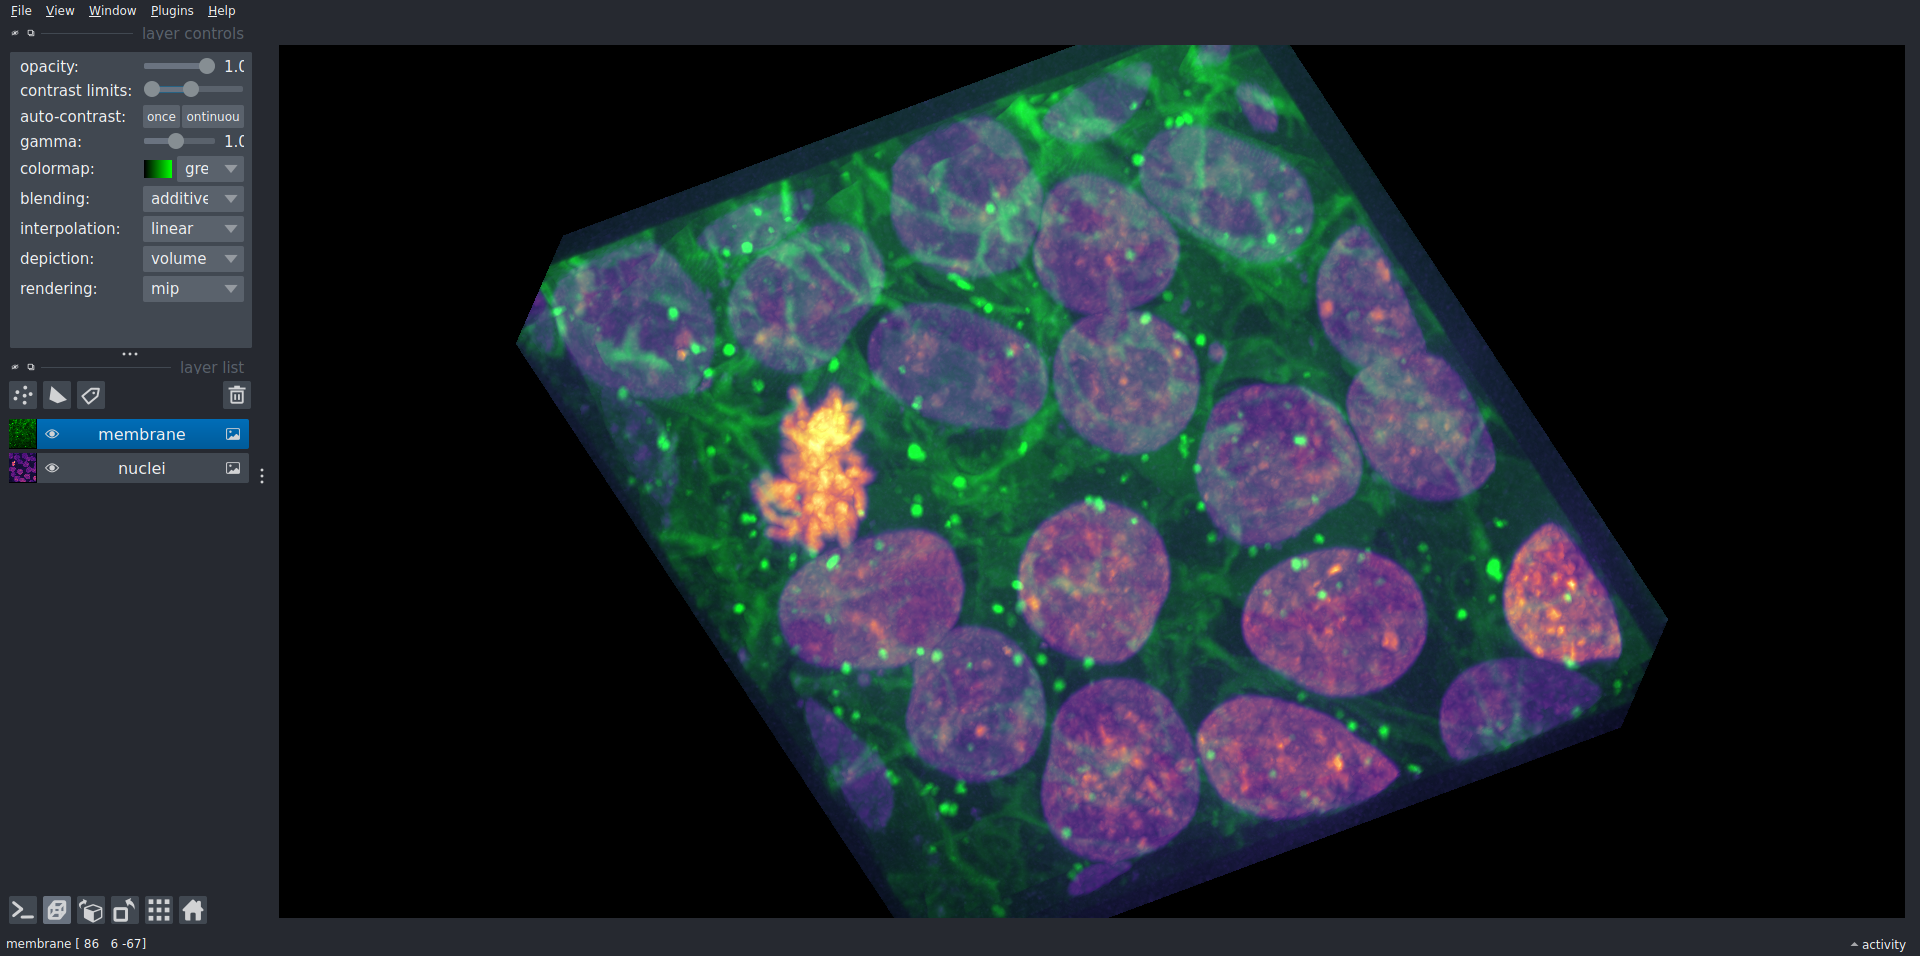

In [30]:
# I manually switched to 3D view
nbscreenshot(viewer)

In [6]:
# Segment nuclei like in main notebook
from skimage.filters import threshold_otsu, gaussian
from scipy import ndimage as ndi 
from skimage.feature import peak_local_max
from skimage.segmentation import watershed, clear_border
import numpy as np

# Blur original image to smooth noise
nuclei_gauss_low = gaussian(nuc, sigma=2)
nuclei_gauss_high = gaussian(nuc, sigma=10)
# Threshold smoothed image with Otsu method
binary = nuclei_gauss_low > threshold_otsu(nuclei_gauss_low)
# Fill holes inside nuclei
binary_cleaned = binary.copy()
for layer_id in range(binary.shape[0]):
    binary_cleaned[layer_id] = ndi.binary_fill_holes(binary[layer_id])
# Calculate the distance transform
dist_transf = ndi.distance_transform_edt(binary_cleaned)
# Find local maxima coordinates from nuclei
coords = peak_local_max(nuclei_gauss_high, 5)
# Transform the max coordinates into an actual image
mask = np.zeros(dist_transf.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)

# Use the distance transform, local max markers and binary mask for watershed
labels = watershed(-dist_transf, markers, mask=binary_cleaned)

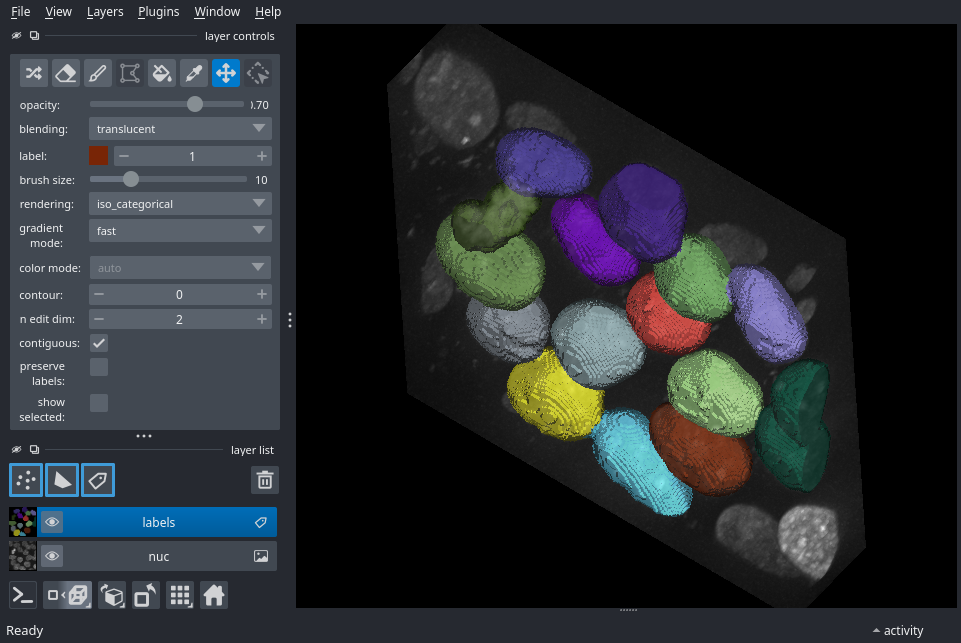

In [9]:
# View data and segmentation in 3D
v = napari.Viewer()
v.add_image(nuc)
v.add_labels(labels, opacity=0.7)
v.dims.ndisplay = 3
v.camera.angles = (3, 38, 53)
nbscreenshot(v)

In [11]:
v.layers

[<Image layer 'nuc' at 0x74d6584a4690>, <Labels layer 'labels' at 0x74d658477620>, <Shapes layer 'labels - Shapes' at 0x74d6584746e0>, <Points layer 'labels - Shapes - Points' at 0x74d631e03380>]